# Factory-to-Customer Shipping Route Efficiency Analysis
### Nassau Candy Distributor

This notebook follows the analytical methodology step by step:

1. Data Cleaning & Validation
2. Feature Engineering
3. Route Definition & Aggregation
4. Efficiency Benchmarking
5. Geographic Bottleneck Analysis
6. Ship Mode Performance Analysis

> **How to use this notebook:** run the grey **code cells** in order (`Shift + Enter`). The white **markdown cells** explain what each code cell does and why, in plain language.
>
> **Column names:** this notebook refers to columns directly by name (e.g. `df["Order Date"]`), matching your field list. If any of your actual column headers are spelled differently, update them in the cells below — a find-and-replace works fine since each name is used as plain text.


## Setup: Import Libraries & Load the Data

Before any of the methodology steps can run, Python needs a few external libraries loaded.

- **pandas** (`pd`) → for working with tables of data (like Excel, but in code)
- **numpy** (`np`) → for numeric operations
- **matplotlib** / **seaborn** → for charts


In [51]:
# "import X as Y" loads a toolkit called X and lets us refer to it using the short name Y
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully")


Libraries loaded successfully


In [52]:
# Load the dataset into a pandas DataFrame (a table: rows and columns)
# Update the file name below to match your actual file
df = pd.read_csv("Nassau Candy Distributor.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()


Dataset loaded: 10,194 rows and 18 columns


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


## 1. Data Cleaning & Validation

Methodology steps covered here:
- Validate date formats
- Remove invalid or negative lead times
- Handle missing shipment records
- Standardise geographic fields


### 1.1 Validate Date Formats

`Order Date` and `Ship Date` are converted from text into real date objects using `pd.to_datetime()`. `errors="coerce"` means any date that can't be read is marked as missing (`NaT`) rather than crashing the notebook, so it can be handled explicitly in the next step.


In [53]:
df["Order Date"] = pd.to_datetime(df["Order Date"],format="%d-%m-%Y", errors="coerce")
df["Ship Date"]  = pd.to_datetime(df["Ship Date"],format="%d-%m-%Y", errors="coerce")

bad_order_dates = df["Order Date"].isna().sum()
bad_ship_dates  = df["Ship Date"].isna().sum()

print(f"Unreadable Order Dates: {bad_order_dates}")
print(f"Unreadable Ship Dates:  {bad_ship_dates}")


Unreadable Order Dates: 0
Unreadable Ship Dates:  0


### 1.2 Handle Missing Shipment Records

Rows missing either date can't produce a valid lead time. We count them, then keep only rows where both dates are present.


In [54]:
missing_dates = df[df["Order Date"].isna() | df["Ship Date"].isna()]
print(f"Rows with missing Order Date or Ship Date: {len(missing_dates):,} "
      f"({len(missing_dates)/len(df)*100:.2f}% of the dataset)")

# "~" means NOT — this keeps rows that are NOT missing either date
df_clean = df[~(df["Order Date"].isna() | df["Ship Date"].isna())].copy()

print(f"Rows remaining: {len(df_clean):,}")


Rows with missing Order Date or Ship Date: 0 (0.00% of the dataset)
Rows remaining: 10,194


### 1.3 Remove Invalid or Negative Lead Times

A shipment can't leave before it was ordered. Rows where `Ship Date` is earlier than `Order Date` are removed.


In [55]:
temp_lead_time = (df_clean["Ship Date"] - df_clean["Order Date"]).dt.days

invalid_rows = (temp_lead_time < 0).sum()
print(f"Rows with a negative lead time: {invalid_rows:,}")

df_clean = df_clean[temp_lead_time >= 0].copy()
print(f"Rows remaining: {len(df_clean):,}")


Rows with a negative lead time: 0
Rows remaining: 10,194


### 1.4 Standardise Geographic Fields

Text fields are stripped of extra spaces and given consistent capitalization (`.str.strip().str.title()`), so that e.g. `"california"` and `"California "` are treated as the same value when grouping later.


In [56]:
geo_columns = ["City", "State/Province", "Region", "Country/Region", "Ship Mode"]

for col in geo_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).str.strip().str.title()

print("Geographic fields standardised")
df_clean[geo_columns].head()


Geographic fields standardised


,City,State/Province,Region,Country/Region,Ship Mode
0,Houston,Texas,Interior,United States,Standard Class
1,Naperville,Illinois,Interior,United States,Standard Class
2,Naperville,Illinois,Interior,United States,Standard Class
3,Naperville,Illinois,Interior,United States,Standard Class
4,Philadelphia,Pennsylvania,Atlantic,United States,Standard Class


## 2. Feature Engineering

Methodology steps covered here:
- Calculate Shipping Lead Time (days)
- Categorise routes by Factory → Customer Region and Factory → Customer State
- Group shipments by ship mode


### 2.1 Calculate Shipping Lead Time (days)

`Lead Time Days` = `Ship Date` − `Order Date`. Subtracting two datetime columns gives a duration; `.dt.days` converts it to a whole number of days.


In [57]:
df_clean["Lead Time Days"] = (df_clean["Ship Date"] - df_clean["Order Date"]).dt.days

df_clean["Lead Time Days"].describe()


count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time Days, dtype: float64

### 2.2 Define Factory (needed to build the route label)

The dataset doesn't include a dedicated factory column, so we treat every shipment as originating from one central factory/distribution center. This gives the route label a starting point, as required by the methodology (`Factory → Customer State/Region`).


In [58]:
df_clean["Factory"] = "Nassau Candy Distribution Center"


### 2.3 Categorise Routes: Factory → Customer Region and Factory → Customer State

Each route is built as a single text label joining Factory and the customer's State (or Region) with an arrow.


In [59]:
df_clean["Route State"]  = df_clean["Factory"] + " → " + df_clean["State/Province"]
df_clean["Route Region"] = df_clean["Factory"] + " → " + df_clean["Region"]

df_clean[["Factory", "State/Province", "Route State", "Region", "Route Region"]].head()


,Factory,State/Province,Route State,Region,Route Region
0,Nassau Candy Distribution Center,Texas,Nassau Candy Distribution Center → Texas,Interior,Nassau Candy Distribution Center → Interior
1,Nassau Candy Distribution Center,Illinois,Nassau Candy Distribution Center → Illinois,Interior,Nassau Candy Distribution Center → Interior
2,Nassau Candy Distribution Center,Illinois,Nassau Candy Distribution Center → Illinois,Interior,Nassau Candy Distribution Center → Interior
3,Nassau Candy Distribution Center,Illinois,Nassau Candy Distribution Center → Illinois,Interior,Nassau Candy Distribution Center → Interior
4,Nassau Candy Distribution Center,Pennsylvania,Nassau Candy Distribution Center → Pennsylvania,Atlantic,Nassau Candy Distribution Center → Atlantic


### 2.4 Group Shipments by Ship Mode

Confirming the ship mode categories after standardisation in Section 1.


In [60]:
df_clean["Ship Mode"].value_counts()


Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

## 3. Route Definition & Aggregation

Each route is defined as: **Factory Location → Customer State / Region**.

For each route, the methodology calls for:
- Total shipments
- Average shipping lead time
- Lead time variability


In [61]:
# .groupby() groups rows sharing the same Route State value
# .agg() calculates the required statistics per group in one step
route_summary = df_clean.groupby("Route State").agg(
    Total_Shipments=("Lead Time Days", "count"),
    Avg_Lead_Time=("Lead Time Days", "mean"),
    Lead_Time_Variability=("Lead Time Days", "std"),
).reset_index().round(2)

print(f"Total distinct routes (State level): {len(route_summary)}")
route_summary.head(10)


Total distinct routes (State level): 59


,Route State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Nassau Candy Distribution Center → Alabama,61,1291.28,253.48
1,Nassau Candy Distribution Center → Alberta,26,1274.08,292.40
2,Nassau Candy Distribution Center → Arizona,224,1309.21,263.39
3,Nassau Candy Distribution Center → Arkansas,60,1285.73,284.75
4,Nassau Candy Distribution Center → British Col...,22,1290.32,308.43
5,Nassau Candy Distribution Center → California,2001,1318.43,264.39
6,Nassau Candy Distribution Center → Colorado,182,1337.19,249.68
7,Nassau Candy Distribution Center → Connecticut,82,1357.55,271.68
8,Nassau Candy Distribution Center → Delaware,96,1269.75,233.93
9,Nassau Candy Distribution Center → District Of...,10,1347.70,153.53


In [62]:
# Same aggregation at the Region level
region_summary = df_clean.groupby("Route Region").agg(
    Total_Shipments=("Lead Time Days", "count"),
    Avg_Lead_Time=("Lead Time Days", "mean"),
    Lead_Time_Variability=("Lead Time Days", "std"),
).reset_index().round(2)

print(f"Total distinct routes (Region level): {len(region_summary)}")
region_summary.head(10)


Total distinct routes (Region level): 4


,Route Region,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Nassau Candy Distribution Center → Atlantic,2986,1322.75,256.54
1,Nassau Candy Distribution Center → Gulf,1620,1311.37,264.73
2,Nassau Candy Distribution Center → Interior,2335,1323.09,262.69
3,Nassau Candy Distribution Center → Pacific,3253,1322.19,266.47


## 4. Efficiency Benchmarking

Methodology steps covered here:
- Rank routes from fastest to slowest
- Identify Top 10 most efficient routes
- Identify Bottom 10 least efficient routes
- Compare performance across ship modes


In [63]:
# Rank routes from fastest to slowest by average lead time
ranked_routes = route_summary.sort_values("Avg_Lead_Time", ascending=True).reset_index(drop=True)
ranked_routes


,Route State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Nassau Candy Distribution Center → Maine,8,1137.12,189.73
1,Nassau Candy Distribution Center → Newfoundlan...,6,1216.17,357.45
2,Nassau Candy Distribution Center → Nevada,39,1226.79,239.77
3,Nassau Candy Distribution Center → Virginia,224,1229.12,256.42
4,Nassau Candy Distribution Center → Ontario,58,1247.47,272.27
5,Nassau Candy Distribution Center → Utah,53,1253.00,289.78
6,Nassau Candy Distribution Center → South Carolina,42,1255.43,241.75
7,Nassau Candy Distribution Center → Louisiana,42,1263.79,306.78
8,Nassau Candy Distribution Center → Mississippi,53,1266.57,263.15
9,Nassau Candy Distribution Center → Oregon,124,1267.71,259.37


In [64]:
# Top 10 Most Efficient Routes (lowest average lead time)
top_10_efficient = ranked_routes.head(10)
top_10_efficient


,Route State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
0,Nassau Candy Distribution Center → Maine,8,1137.12,189.73
1,Nassau Candy Distribution Center → Newfoundlan...,6,1216.17,357.45
2,Nassau Candy Distribution Center → Nevada,39,1226.79,239.77
3,Nassau Candy Distribution Center → Virginia,224,1229.12,256.42
4,Nassau Candy Distribution Center → Ontario,58,1247.47,272.27
5,Nassau Candy Distribution Center → Utah,53,1253.00,289.78
6,Nassau Candy Distribution Center → South Carolina,42,1255.43,241.75
7,Nassau Candy Distribution Center → Louisiana,42,1263.79,306.78
8,Nassau Candy Distribution Center → Mississippi,53,1266.57,263.15
9,Nassau Candy Distribution Center → Oregon,124,1267.71,259.37


In [65]:
# Bottom 10 Least Efficient Routes (highest average lead time)
bottom_10_inefficient = ranked_routes.sort_values("Avg_Lead_Time", ascending=False).head(10)
bottom_10_inefficient


,Route State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
58,Nassau Candy Distribution Center → West Virginia,4,1638.00,2.00
57,Nassau Candy Distribution Center → North Dakota,7,1637.86,1.46
56,Nassau Candy Distribution Center → Saskatchewan,2,1457.00,258.80
55,Nassau Candy Distribution Center → Manitoba,12,1455.33,191.14
54,Nassau Candy Distribution Center → Iowa,30,1443.90,229.80
53,Nassau Candy Distribution Center → New Mexico,37,1441.84,267.20
52,Nassau Candy Distribution Center → Vermont,11,1438.91,191.00
51,Nassau Candy Distribution Center → Prince Edwa...,10,1420.30,255.81
50,Nassau Candy Distribution Center → South Dakota,12,1395.92,360.35
49,Nassau Candy Distribution Center → Tennessee,183,1391.49,248.20


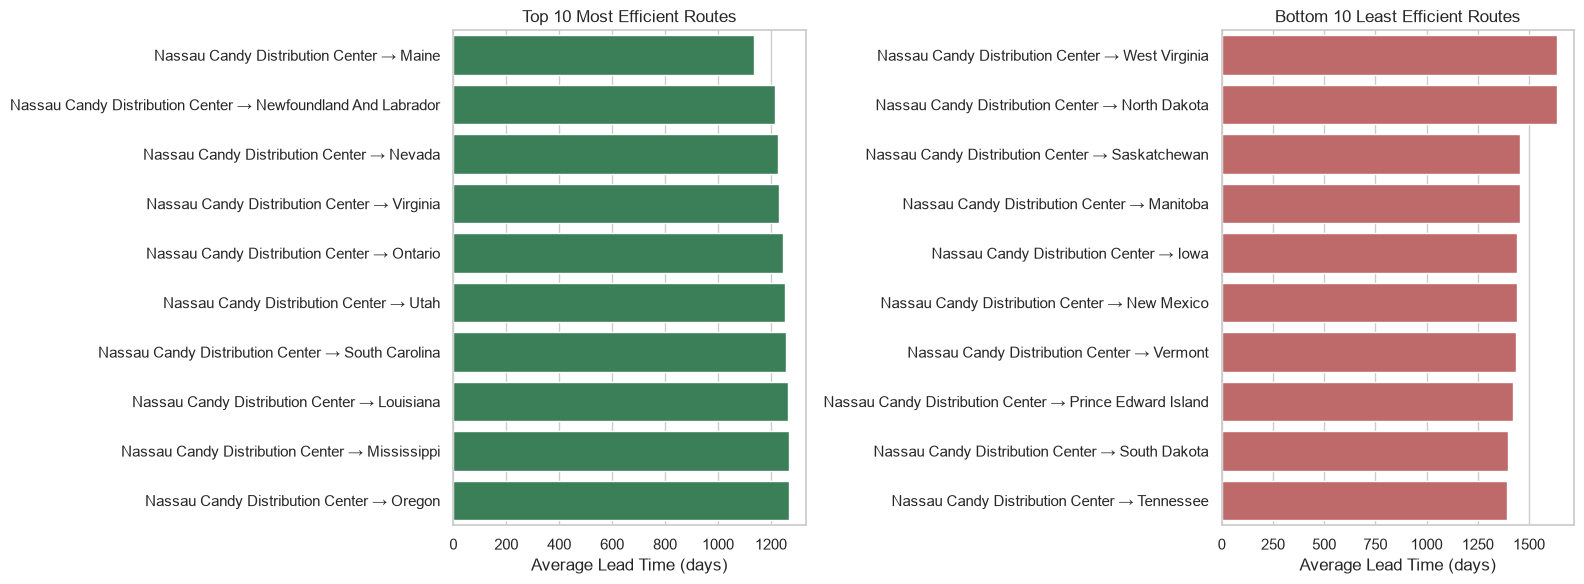

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=top_10_efficient, y="Route State", x="Avg_Lead_Time",
            ax=axes[0], color="seagreen")
axes[0].set_title("Top 10 Most Efficient Routes")
axes[0].set_xlabel("Average Lead Time (days)")
axes[0].set_ylabel("")

sns.barplot(data=bottom_10_inefficient, y="Route State", x="Avg_Lead_Time",
            ax=axes[1], color="indianred")
axes[1].set_title("Bottom 10 Least Efficient Routes")
axes[1].set_xlabel("Average Lead Time (days)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


### 4.1 Compare Performance Across Ship Modes


In [67]:
ship_mode_summary = df_clean.groupby("Ship Mode").agg(
    Total_Shipments=("Lead Time Days", "count"),
    Avg_Lead_Time=("Lead Time Days", "mean"),
    Lead_Time_Variability=("Lead Time Days", "std"),
).reset_index().round(2)

ship_mode_summary = ship_mode_summary.sort_values("Avg_Lead_Time")
ship_mode_summary


,Ship Mode,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
3,Standard Class,6120,1314.33,262.40
2,Second Class,1979,1323.85,261.81
1,Same Day,547,1333.44,253.81
0,First Class,1548,1338.28,265.63


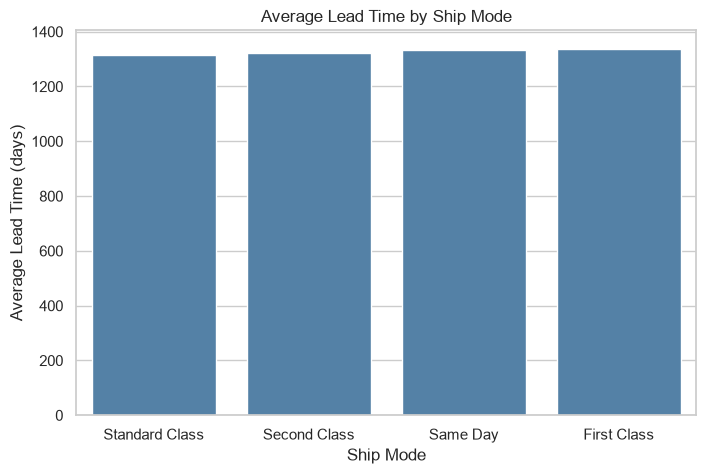

In [68]:
plt.figure(figsize=(8, 5))
sns.barplot(data=ship_mode_summary, x="Ship Mode", y="Avg_Lead_Time", color="steelblue")
plt.title("Average Lead Time by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Lead Time (days)")
plt.show()


## 5. Geographic Bottleneck Analysis

Methodology steps covered here:
- Identify regions with high average lead time
- Identify regions with high shipment volume + poor performance
- Detect congestion-prone states or regions


### 5.1 Regions with High Average Lead Time

"High" is defined as above the overall average lead time across all shipments.


In [69]:
overall_avg_lead_time = df_clean["Lead Time Days"].mean()
print(f"Overall average lead time across all shipments: {overall_avg_lead_time:.2f} days")

high_lead_time_regions = region_summary[
    region_summary["Avg_Lead_Time"] > overall_avg_lead_time
].sort_values("Avg_Lead_Time", ascending=False)

high_lead_time_regions


Overall average lead time across all shipments: 1320.84 days


,Route Region,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
2,Nassau Candy Distribution Center → Interior,2335,1323.09,262.69
0,Nassau Candy Distribution Center → Atlantic,2986,1322.75,256.54
3,Nassau Candy Distribution Center → Pacific,3253,1322.19,266.47


### 5.2 Regions with High Shipment Volume + Poor Performance

"High volume" is defined as the top 25% of regions by shipment count (75th percentile). Combined with above-average lead time, this identifies the routes where delays affect the most shipments.


In [70]:
volume_threshold = region_summary["Total_Shipments"].quantile(0.75)
print(f"High-volume threshold (75th percentile of shipment count): {volume_threshold:.0f} shipments")

high_volume_poor_performance = region_summary[
    (region_summary["Avg_Lead_Time"] > overall_avg_lead_time) &
    (region_summary["Total_Shipments"] >= volume_threshold)
].sort_values("Avg_Lead_Time", ascending=False)

high_volume_poor_performance


High-volume threshold (75th percentile of shipment count): 3053 shipments


,Route Region,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
3,Nassau Candy Distribution Center → Pacific,3253,1322.19,266.47


### 5.3 Congestion-Prone States or Regions

States/regions with the highest shipment volume overall — the areas most likely to experience congestion regardless of current average speed.


In [71]:
congestion_prone_states = route_summary.sort_values("Total_Shipments", ascending=False).head(10)
congestion_prone_states


,Route State,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
5,Nassau Candy Distribution Center → California,2001,1318.43,264.39
34,Nassau Candy Distribution Center → New York,1128,1324.49,249.36
51,Nassau Candy Distribution Center → Texas,985,1310.31,266.73
43,Nassau Candy Distribution Center → Pennsylvania,587,1324.20,261.76
55,Nassau Candy Distribution Center → Washington,506,1360.66,272.12
13,Nassau Candy Distribution Center → Illinois,492,1323.15,269.72
39,Nassau Candy Distribution Center → Ohio,469,1325.73,263.98
10,Nassau Candy Distribution Center → Florida,383,1311.40,269.81
23,Nassau Candy Distribution Center → Michigan,255,1300.56,244.05
36,Nassau Candy Distribution Center → North Carolina,249,1334.88,254.99


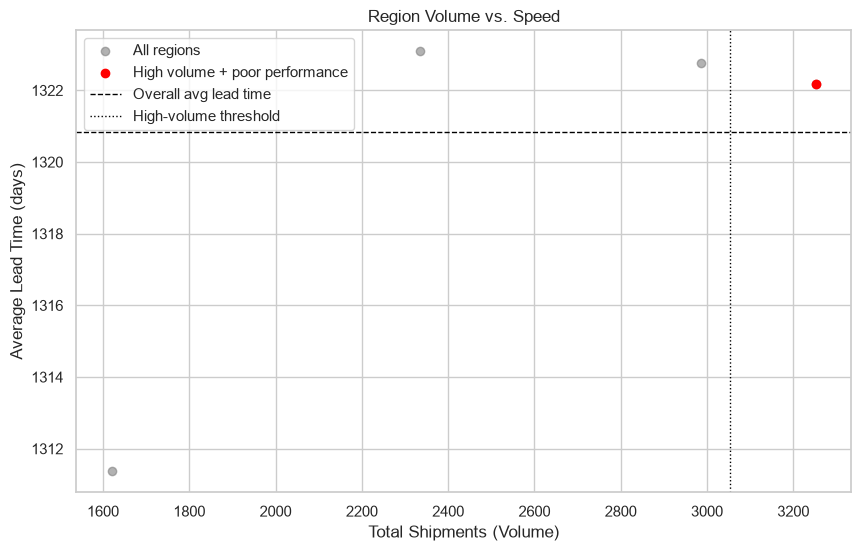

In [72]:
plt.figure(figsize=(10, 6))
plt.scatter(region_summary["Total_Shipments"], region_summary["Avg_Lead_Time"],
            alpha=0.6, color="grey", label="All regions")
plt.scatter(high_volume_poor_performance["Total_Shipments"], high_volume_poor_performance["Avg_Lead_Time"],
            color="red", label="High volume + poor performance")

plt.axhline(overall_avg_lead_time, color="black", linestyle="--", linewidth=1,
            label="Overall avg lead time")
plt.axvline(volume_threshold, color="black", linestyle=":", linewidth=1,
            label="High-volume threshold")

plt.xlabel("Total Shipments (Volume)")
plt.ylabel("Average Lead Time (days)")
plt.title("Region Volume vs. Speed")
plt.legend()
plt.show()


## 6. Ship Mode Performance Analysis

Methodology steps covered here:
- Compare shipping efficiency by Standard shipping and Expedited shipping
- Evaluate cost-time tradeoffs (descriptive)


### 6.1 Compare Shipping Efficiency by Ship Mode

Reuses `ship_mode_summary` from Section 4.1 — shown again here for reference alongside the cost-time view below.


In [73]:
ship_mode_summary


,Ship Mode,Total_Shipments,Avg_Lead_Time,Lead_Time_Variability
3,Standard Class,6120,1314.33,262.40
2,Second Class,1979,1323.85,261.81
1,Same Day,547,1333.44,253.81
0,First Class,1548,1338.28,265.63


### 6.2 Cost-Time Tradeoffs (Descriptive)

Average sales, gross profit, cost, and margin per ship mode, alongside average lead time — a descriptive view of what faster shipping costs in profit margin, not a full cost model.


In [74]:
cost_time_summary = df_clean.groupby("Ship Mode").agg(
    Total_Shipments=("Lead Time Days", "count"),
    Avg_Lead_Time=("Lead Time Days", "mean"),
    Avg_Sales=("Sales", "mean"),
    Avg_Gross_Profit=("Gross Profit", "mean"),
    Avg_Cost=("Cost", "mean"),
).reset_index().round(2)

# Gross profit margin = Gross Profit / Sales, expressed as a percentage
cost_time_summary["Avg_Gross_Profit_Margin_%"] = (
    cost_time_summary["Avg_Gross_Profit"] / cost_time_summary["Avg_Sales"] * 100
).round(2)

cost_time_summary = cost_time_summary.sort_values("Avg_Lead_Time")
cost_time_summary


,Ship Mode,Total_Shipments,Avg_Lead_Time,Avg_Sales,Avg_Gross_Profit,Avg_Cost,Avg_Gross_Profit_Margin_%
3,Standard Class,6120,1314.33,13.97,9.22,4.75,66.00
2,Second Class,1979,1323.85,14.08,9.25,4.83,65.70
1,Same Day,547,1333.44,13.00,8.59,4.41,66.08
0,First Class,1548,1338.28,13.77,9.05,4.72,65.72


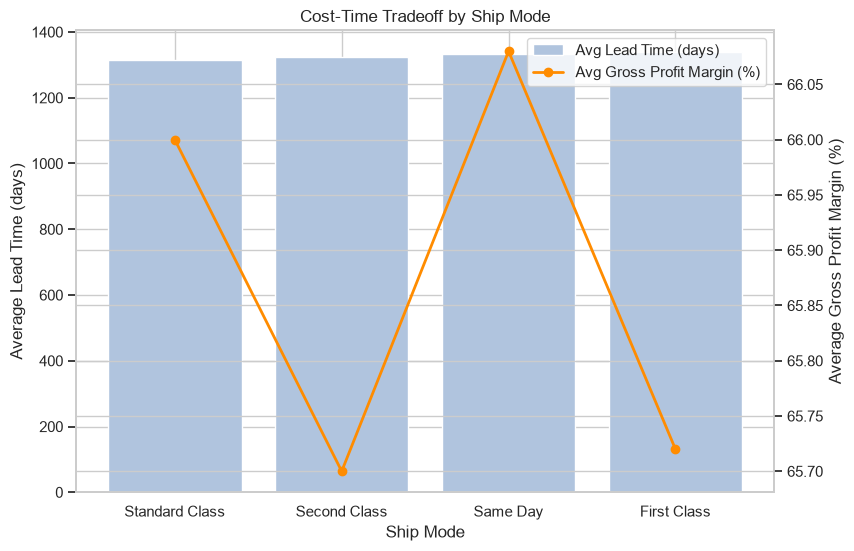

In [75]:
fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.bar(cost_time_summary["Ship Mode"], cost_time_summary["Avg_Lead_Time"],
        color="lightsteelblue", label="Avg Lead Time (days)")
ax1.set_ylabel("Average Lead Time (days)")
ax1.set_xlabel("Ship Mode")

ax2 = ax1.twinx()
ax2.plot(cost_time_summary["Ship Mode"], cost_time_summary["Avg_Gross_Profit_Margin_%"],
          color="darkorange", marker="o", linewidth=2, label="Avg Gross Profit Margin (%)")
ax2.set_ylabel("Average Gross Profit Margin (%)")

plt.title("Cost-Time Tradeoff by Ship Mode")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.show()
